<a href="https://colab.research.google.com/github/Cshoga/RockPaperScissors-ML-Pipeline/blob/main/notebook/Rockpaperscissors_ML_Pipeline_Summative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("drgfreeman/rockpaperscissors")

print("Path to dataset files:", path)

100%|██████████| 306M/306M [00:01<00:00, 168MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/drgfreeman/rockpaperscissors/versions/2


In [2]:
import os
classes = [folder for folder in os.listdir(path) if os.path.isdir(os.path.join(path, folder))]
print(classes)

['rps-cv-images', 'paper', 'scissors', 'rock']


In [3]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn

In [4]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [5]:
import os

rock_path = os.path.join(path, "rock")
paper_path = os.path.join(path, "paper")
scissors_path = os.path.join(path, "scissors")

print(rock_path)
print(paper_path)
print(scissors_path)

/root/.cache/kagglehub/datasets/drgfreeman/rockpaperscissors/versions/2/rock
/root/.cache/kagglehub/datasets/drgfreeman/rockpaperscissors/versions/2/paper
/root/.cache/kagglehub/datasets/drgfreeman/rockpaperscissors/versions/2/scissors


In [6]:
print("Rock images:", len(os.listdir(rock_path)))
print("Paper images:", len(os.listdir(paper_path)))
print("Scissors images:", len(os.listdir(scissors_path)))

Rock images: 726
Paper images: 712
Scissors images: 750


In [7]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    image_size=(224,224),
    batch_size=32
)

print(dataset.class_names)

Found 4376 files belonging to 4 classes.
['paper', 'rock', 'rps-cv-images', 'scissors']


In [8]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 4376 files belonging to 4 classes.
Using 3501 files for training.
Found 4376 files belonging to 4 classes.
Using 875 files for validation.


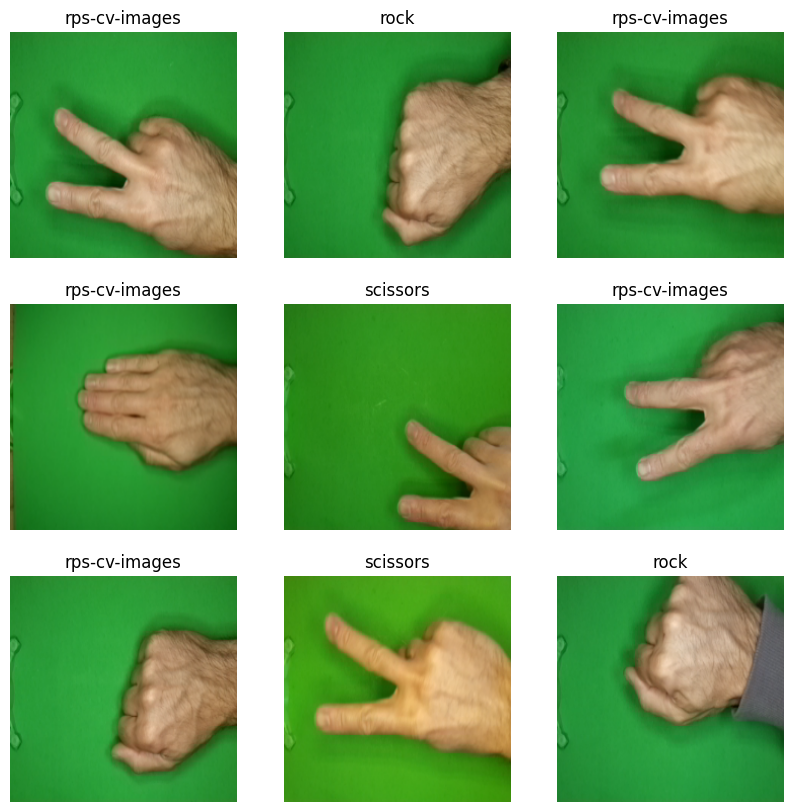

In [9]:
plt.figure(figsize=(10,10))

class_names = dataset.class_names

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

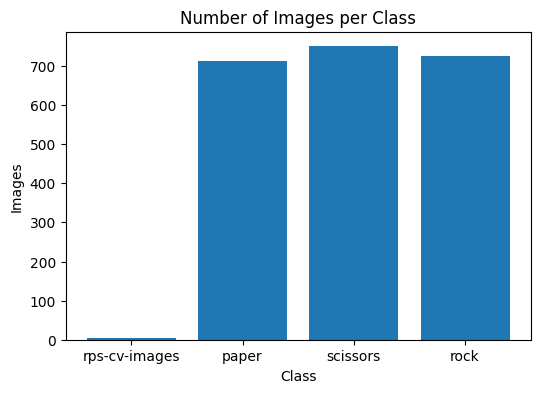

In [10]:
counts = []

for folder in classes:
    counts.append(len(os.listdir(os.path.join(path,folder))))

plt.figure(figsize=(6,4))
plt.bar(classes,counts)
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Images")
plt.show()

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [12]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [13]:
model = Sequential([

    # First Convolution Layer
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(2,2),

    # Second Convolution Layer
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    # Third Convolution Layer
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,631,299 (21.48 MB)

 Trainable params: 5,631,299 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 27s 131ms/step - accuracy: 0.4981 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.4987 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.4987 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.4987 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.4987 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.4987 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.4987 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 8/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.4987 - loss: nan - val_accuracy: 0.5051 - val_loss: nan
Epoch 9/15

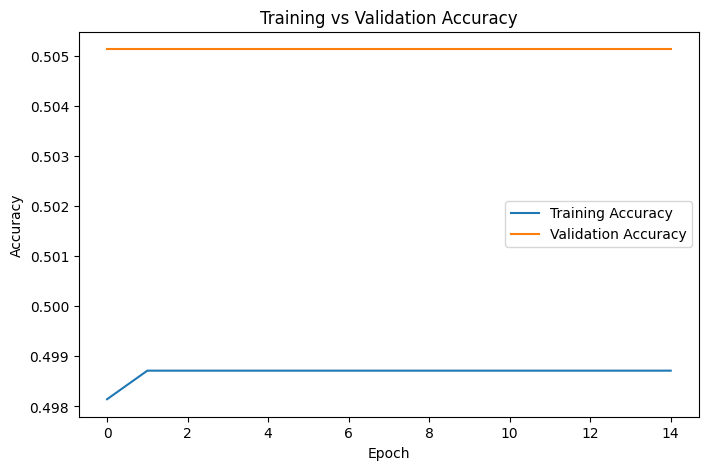

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

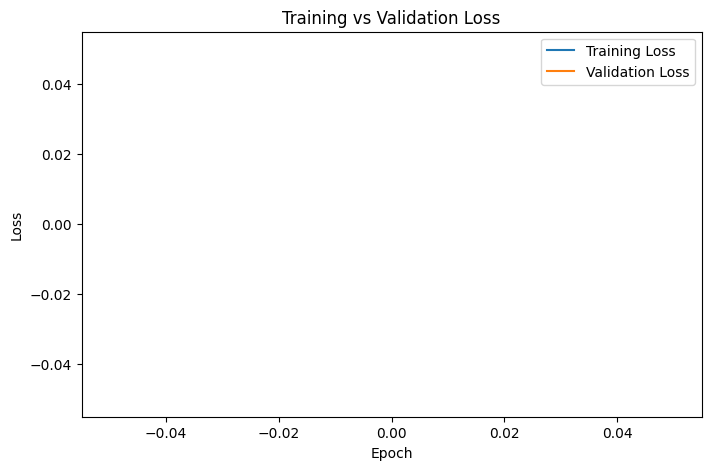

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(validation_dataset)

print("Validation Accuracy:", test_accuracy)
print("Validation Loss:", test_loss)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5051 - loss: nan
Validation Accuracy: 0.505142867565155
Validation Loss: nan


In [20]:
import os
os.makedirs("models", exist_ok=True)

In [21]:
model.save("models/rock_paper_scissors_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [22]:
# Predict probabilities
predictions = model.predict(validation_dataset)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step


In [23]:
# Get actual labels
y_true = np.concatenate(
    [labels.numpy() for images, labels in validation_dataset]
)
print("True labels:", len(y_true))
print("Predicted labels:", len(y_pred))

True labels: 875
Predicted labels: 875


In [24]:
accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"Precision: {precision:.4f}")
recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"Recall: {recall:.4f}")
f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"F1 Score: {f1:.4f}")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Accuracy: 0.1554
Precision: 0.0242
Recall: 0.1554
F1 Score: 0.0418
               precision    recall  f1-score   support

        paper       0.16      1.00      0.27       136
         rock       0.00      0.00      0.00       147
rps-cv-images       0.00      0.00      0.00       442
     scissors       0.00      0.00      0.00       150

     accuracy                           0.16       875
    macro avg       0.04      0.25      0.07       875
 weighted avg       0.02      0.16      0.04       875



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

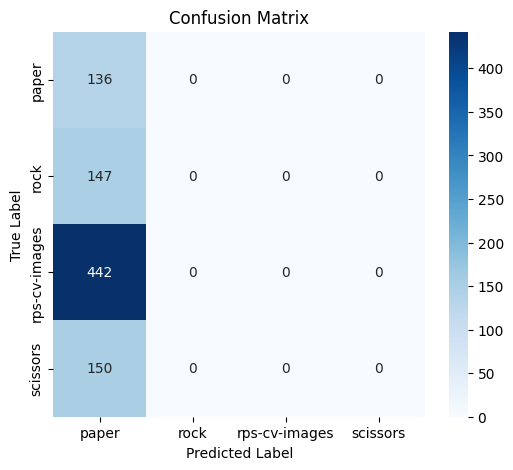

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [26]:
import pandas as pd

results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

results

,Metric,Score
0,Accuracy,0.155429
1,Precision,0.024158
2,Recall,0.155429
3,F1 Score,0.041817


In [27]:
import os

new_data_path = "data/new_data"
classes = ["rock", "paper", "scissors"]
for cls in classes:
    os.makedirs(os.path.join(new_data_path, cls), exist_ok=True)

print("New data folders created successfully.")

New data folders created successfully.


In [28]:
original_train_path = path

In [29]:
retrain_dataset = tf.keras.utils.image_dataset_from_directory(

    original_train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32

)

Found 4376 files belonging to 4 classes.
Using 3501 files for training.


In [30]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

retrain_dataset = retrain_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [31]:
def retrain_model(model, dataset, epochs=5):

    print("Retraining model...")
    history = model.fit(
        dataset,
        epochs=epochs
    )

    print("Retraining completed.")

    return history

In [32]:
history_retrain = retrain_model(
    model,
    retrain_dataset,
    epochs=5
)

Retraining model...
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.4987 - loss: nan
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.4987 - loss: nan
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.4987 - loss: nan
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.4987 - loss: nan
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.4987 - loss: nan
Retraining completed.


In [33]:
import os

def trigger_retraining():

    retrain_model(
        model,
        retrain_dataset,
        epochs=5
    )
    os.makedirs("models", exist_ok=True)
    model.save(
        "models/rock_paper_scissors_model_updated.keras"
    )

    print("Retraining Triggered Successfully.")

In [34]:
trigger_retraining()

Retraining model...
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.4987 - loss: nan
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.4987 - loss: nan
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.4987 - loss: nan
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.4987 - loss: nan
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.4987 - loss: nan
Retraining completed.
Retraining Triggered Successfully.


In [35]:
from google.colab import files
import os

# First, let's check if the directory exists and what's inside it
if os.path.exists("models"):
    print("Contents of 'models' directory:", os.listdir("models"))
else:
    print("'models' directory does not exist.")

# Attempt to download the file
files.download("models/rock_paper_scissors_model_updated.keras")

Contents of 'models' directory: ['rock_paper_scissors_model_updated.keras', 'rock_paper_scissors_model.keras']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

plt.savefig("images/class_distribution.png")
plt.savefig("images/training_accuracy.png")
plt.savefig("images/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [37]:
from google.colab import files

files.download("images/class_distribution.png")
files.download("images/training_accuracy.png")
files.download("images/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>